In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
import json
from collections import Counter

import pandas as pd

from src.response_parser import ResponseParser

In [12]:
# Load the dataset
df = pd.read_csv("data/structure-explain-results-v1.csv")

# Load official action primitives
with open("action_primitives.json") as f:
    official_primitives = json.load(f)

# Get official primitive names
official_names = [primitive["action"] for primitive in official_primitives]

parser = ResponseParser()

# Extract all action primitives from the dataset
all_primitives_used = []
primitive_counter = Counter()


for idx, row in df.iterrows():
    explain_content = row["explain"]
    if pd.notna(explain_content) and explain_content.strip():
        # Extract action primitives from this explain section
        primitives = parser.extract_action_primitives(explain_content)
        all_primitives_used.extend(primitives)
        primitive_counter.update(primitives)

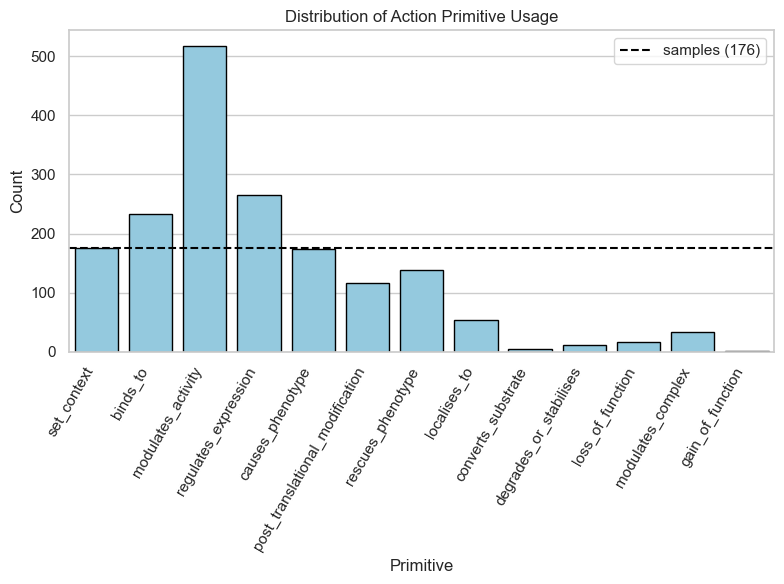

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Convert primitive_counter to DataFrame
primitive_df = pd.DataFrame.from_dict(primitive_counter, orient="index", columns=["count"]).reset_index()
primitive_df = primitive_df.rename(columns={"index": "primitive"})

sns.barplot(data=primitive_df, x="primitive", y="count", color="skyblue", edgecolor="black")
# Add a dashed line for the total number of unique explain samples
total_unique_explain = df["explain"].nunique()
plt.axhline(total_unique_explain, color="black", linestyle="--", label=f"samples ({total_unique_explain})")

plt.xticks(rotation=60, ha="right")
plt.xlabel("Primitive")
plt.ylabel("Count")
plt.title("Distribution of Action Primitive Usage")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
df

,index,question,thinking,answer,explain,dag,raw_response,success,error,input_perturbation,input_report_text
0,0,How does the following perturbation influence ...,Let me analyze this step by step:\n\n1. Contex...,Bevacizumab is a humanized monoclonal antibody...,"set_context(id=""n0"", cell_type=""endothelial ce...","edge(""n1"", ""n2"", relation=""causal"")\nedge(""n2""...",<think>\nLet me analyze this step by step:\n\n...,True,NaN,{'context': {'perturbation_type': 'soluble fac...,# Comprehensive Mechanistic Report: Bevacizuma...
1,1,How does the following perturbation influence ...,Let me analyze this step by step:\n\n1. **Cont...,Nintedanib acts as an ATP-competitive inhibito...,"set_context(id=""n0"", cell_type=""endothelial ce...","edge(""n1"", ""n2"", relation=""causal"")\nedge(""n2""...",<think>\nLet me analyze this step by step:\n\n...,True,NaN,{'context': {'perturbation_type': 'soluble fac...,\n# Mechanistic Report: Nintedanib's Inhibitor...
2,2,How does the following perturbation influence ...,Let me analyze this step by step:\n\n1. Contex...,Apatinib functions as an ATP-competitive inhib...,"set_context(id=""n0"", cell_type=""endothelial ce...","edge(""n1"", ""n3"", relation=""causal"")\nedge(""n2""...",<think>\nLet me analyze this step by step:\n\n...,True,NaN,{'context': {'perturbation_type': 'soluble fac...,\n# Mechanistic Report: Apatinib in VEGF-Media...
3,3,How does the following perturbation influence ...,Let me analyze this step by step:\n\n1. Contex...,Lenvatinib competitively binds to the ATP-bind...,"set_context(id=""n0"", cell_type=""endothelial ce...","edge(""n1"", ""n2"", relation=""causal"")\nedge(""n2""...",<think>\nLet me analyze this step by step:\n\n...,True,NaN,{'context': {'perturbation_type': 'soluble fac...,\n# Mechanistic Report: Impact of Lenvatinib o...
4,4,How does the following perturbation influence ...,Let me analyze this step by step:\n\n1. Contex...,Motesanib competitively binds to the ATP-bindi...,"set_context(id=""n0"", cell_type=""endothelial ce...","edge(""n1"", ""n2"", relation=""causal"")\nedge(""n2""...",<think>\nLet me analyze this step by step:\n\n...,True,NaN,{'context': {'perturbation_type': 'soluble fac...,# Motesanib: A Multi-Targeted Tyrosine Kinase ...
...,...,...,...,...,...,...,...,...,...,...,...
171,171,How does the following perturbation influence ...,Let me work through this step by step:\n\n1. C...,Solcitinib binds competitively to the ATP-bind...,"set_context(id=""n0"", cell_type=""immune cells"",...","edge(""n1"", ""n2"", relation=""causal"")\nedge(""n2""...",<think>\nLet me work through this step by step...,True,NaN,{'context': {'perturbation_type': 'soluble fac...,\n# Mechanistic Report: Solcitinib's Impact on...
172,172,How does the following perturbation influence ...,Let me work through this step by step.\n\nThe ...,TG 101209 binds competitively to the ATP-bindi...,"set_context(id=""n0"", cell_type=""immune cells"",...","edge(""n1"", ""n2"", relation=""causal"")\nedge(""n2""...",<think>\nLet me work through this step by step...,True,NaN,{'context': {'perturbation_type': 'soluble fac...,\n# Mechanistic Analysis of TG 101209 in IFN-g...
173,173,How does the following perturbation influence ...,Let me work through this step by step:\n\n1. C...,TG 101348 acts as an ATP-competitive inhibitor...,"set_context(id=""n0"", cell_type=""immune cells"",...","edge(""n1"", ""n3"", relation=""causal"")\nedge(""n2""...",<think>\nLet me work through this step by step...,True,NaN,{'context': {'perturbation_type': 'soluble fac...,\n# Mechanistic Analysis of TG 101348 in IFNγ-...
174,174,How does the following perturbation influence ...,Let me work through this step by step:\n\n1. C...,AZ 960 binds directly to the ATP-binding pocke...,"set_context(id=""n0"", cell_type=""immune cells"",...","edge(""n1"", ""n2"", relation=""causal"")\nedge(""n2""...",<think>\nLet me work through this step by step...,True,NaN,{'context': {'perturbation_type': 'soluble fac...,\n# Mechanistic Report

In [38]:
print("\n-----------------------------\n".join(df["question"].iloc[[56, 65]].tolist()))

How does the following perturbation influence the cell in the described context, mechanistically and functionally?**  

{'context': {'perturbation_type': 'loss-of-function', 'description': 'CRISPR knockdown of the PTEN gene', 'cell_type': 'N/A', 'disease_model': 'Cowden syndrome'}, 'perturbation': {'type': 'chemical', 'smiles': 'CC1=C2C=C(C(=O)N(C2=NC(=N1)N)C3CCC(CC3)OCCO)C4=CN=C(C=C4)OC', 'name': 'PF 04691502', 'target': 'PI-3K', 'moa_type': 'inhibitor'}}
-----------------------------
How does the following perturbation influence the cell in the described context, mechanistically and functionally?**  

{'context': {'perturbation_type': 'loss-of-function', 'description': 'CRISPR knockdown of the PTEN gene', 'cell_type': 'N/A', 'disease_model': 'Cowden syndrome'}, 'perturbation': {'type': 'chemical', 'smiles': 'CC1=C2C=C(C(=O)N(C2=NC(=N1)N)C3CCC(CC3)OCCO)C4=CN=C(C=C4)OC', 'name': 'PF 04691502', 'target': 'PI-3K', 'moa_type': 'inhibitor'}}


In [40]:
print("\n-----------------------------\n".join(df["answer"].iloc[[56, 65]].tolist()))

PF-04691502 binds and competitively inhibits both PI3K and mTOR kinases at their ATP-binding sites, directly counteracting the hyperactive PI3K/AKT/mTOR signaling caused by PTEN loss in Cowden syndrome. This dual inhibition reduces AKT phosphorylation at both T308 and S473 sites, blocks mTORC1-mediated protein synthesis, and induces G1 cell cycle arrest through p27 upregulation and cyclin D1 downregulation. The compound mechanistically rescues the pathological hyperproliferation, increased cell size, and metabolic alterations characteristic of PTEN-deficient cells by essentially replacing PTEN's tumor suppressor function through pharmacological pathway inhibition. The primary functional outcome is restoration of normal growth control and reversal of the hamartomatous proliferative phenotype underlying Cowden syndrome pathogenesis.
-----------------------------
PF 04691502 binds competitively to the ATP-binding pocket of PI3K, directly inhibiting its kinase activity and preventing PIP2 

In [36]:
print("\n-----------------------------\n".join(df["explain"].iloc[[56, 65]].tolist()))

set_context(id="n0", cell_type="fibroblast", disease_context="Cowden syndrome", prior_perturbation="PTEN CRISPR knockdown")
binds_to(id="n1", actor="PF-04691502", target="PI3K", affinity="7.5-47 nM", via="ATP-competitive inhibition")
binds_to(id="n2", actor="PF-04691502", target="mTOR", affinity="32 nM", via="ATP-competitive inhibition")
modulates_activity(id="n3", entity="PI3K", direction="down", via="competitive ATP site occupancy")
modulates_activity(id="n4", entity="mTORC1", direction="down", via="kinase domain inhibition")
modulates_activity(id="n5", entity="mTORC2", direction="down", via="kinase domain inhibition")
post_translational_modification(id="n6", protein="AKT", mod_type="phosphorylation", site="T308", direction="down", via="reduced PI3K-PDK1 signaling")
post_translational_modification(id="n7", protein="AKT", mod_type="phosphorylation", site="S473", direction="down", via="mTORC2 inhibition")
modulates_activity(id="n8", entity="AKT", direction="down", via="loss of activati

In [39]:
print("\n-----------------------------\n".join(df["explain"].iloc[[107, 111]].tolist()))

set_context(id="n0", cell_type="immune cell", disease_context="pathway biology modulation", prior_perturbation="SOCS3 CRISPR knockdown")
binds_to(id="n1", actor="AZ960", target="JAK2", affinity="low nanomolar", via="ATP-competitive inhibition")
binds_to(id="n2", actor="AZ960", target="JAK3", affinity="low nanomolar", via="ATP-competitive inhibition")
modulates_activity(id="n3", entity="JAK2", direction="down", via="kinase domain inhibition")
modulates_activity(id="n4", entity="JAK3", direction="down", via="kinase domain inhibition")
modulates_activity(id="n5", entity="STAT3", direction="down", via="reduced phosphorylation by JAK2/3")
regulates_expression(id="n6", source="STAT3", gene_or_signature=["IL6", "TNF", "IL17A"], direction="down", via="loss of STAT3 nuclear translocation")
regulates_expression(id="n7", source="STAT3", gene_or_signature=["proliferation markers"], direction="down", via="reduced STAT3-dependent transcription")
rescues_phenotype(id="n8", actor="AZ960", abnormal_phe

In [13]:
# Get unique primitives used
unique_primitives_used = list(set(all_primitives_used))

print(f"\nTotal primitive calls: {len(all_primitives_used)}")
print(f"Unique primitives used: {len(unique_primitives_used)}")

print(f"\nPrimitives used in dataset ({len(unique_primitives_used)}):")
for name in sorted(unique_primitives_used):
    count = primitive_counter[name]
    print(f"  - {name} (used {count} times)")

print("\n" + "=" * 60)

# Compare with official list
official_set = set(official_names)
used_set = set(unique_primitives_used)

# Find missing primitives (in official list but not used)
missing_primitives = official_set - used_set
print(f"\nPrimitives defined but NOT used ({len(missing_primitives)}):")
for name in sorted(missing_primitives):
    print(f"  - {name}")

# Find additional primitives (used but not in official list)
additional_primitives = used_set - official_set
print(f"\nPrimitives used but NOT in official list ({len(additional_primitives)}):")
for name in sorted(additional_primitives):
    count = primitive_counter[name]
    print(f"  - {name} (used {count} times)")

print("\n" + "=" * 60)

# Usage statistics
print("\nUsage Statistics:")
print(
    f"Coverage: {len(used_set)}/{len(official_set)} = {len(used_set) / len(official_set) * 100:.1f}% of official primitives used"
)

if additional_primitives:
    print(f"Extensions: {len(additional_primitives)} non-official primitives found")

print("\nMost frequently used primitives:")
for name, count in primitive_counter.most_common(10):
    print(f"  {name}: {count} times")

print("\nLeast frequently used primitives:")
for name, count in primitive_counter.most_common()[-10:]:
    if count > 0:
        print(f"  {name}: {count} times")


Total primitive calls: 1740
Unique primitives used: 13

Primitives used in dataset (13):
  - binds_to (used 233 times)
  - causes_phenotype (used 173 times)
  - converts_substrate (used 4 times)
  - degrades_or_stabilises (used 12 times)
  - gain_of_function (used 1 times)
  - localises_to (used 53 times)
  - loss_of_function (used 17 times)
  - modulates_activity (used 518 times)
  - modulates_complex (used 33 times)
  - post_translational_modification (used 116 times)
  - regulates_expression (used 266 times)
  - rescues_phenotype (used 138 times)
  - set_context (used 176 times)


Primitives defined but NOT used (6):
  - cell_cell_interaction
  - chromatin_modification
  - correlates_with
  - participates_in
  - regulates_translation
  - similar_to

Primitives used but NOT in official list (0):


Usage Statistics:
Coverage: 13/19 = 68.4% of official primitives used

Most frequently used primitives:
  modulates_activity: 518 times
  regulates_expression: 266 times
  binds_to: 233 ti

Analyzing 176 records for pathway-related primitives...

Total primitive calls: 1740
Pathway-related primitive calls: 158
Percentage involving pathways: 9.1%

PATHWAY-RELATED PRIMITIVES DISTRIBUTION:

Primitives used with 'pathway' context:
  modulates_activity: 56 times (35.4%)
  regulates_expression: 37 times (23.4%)
  rescues_phenotype: 33 times (20.9%)
  causes_phenotype: 16 times (10.1%)
  set_context: 13 times (8.2%)
  post_translational_modification: 1 times (0.6%)
  localises_to: 1 times (0.6%)
  modulates_complex: 1 times (0.6%)


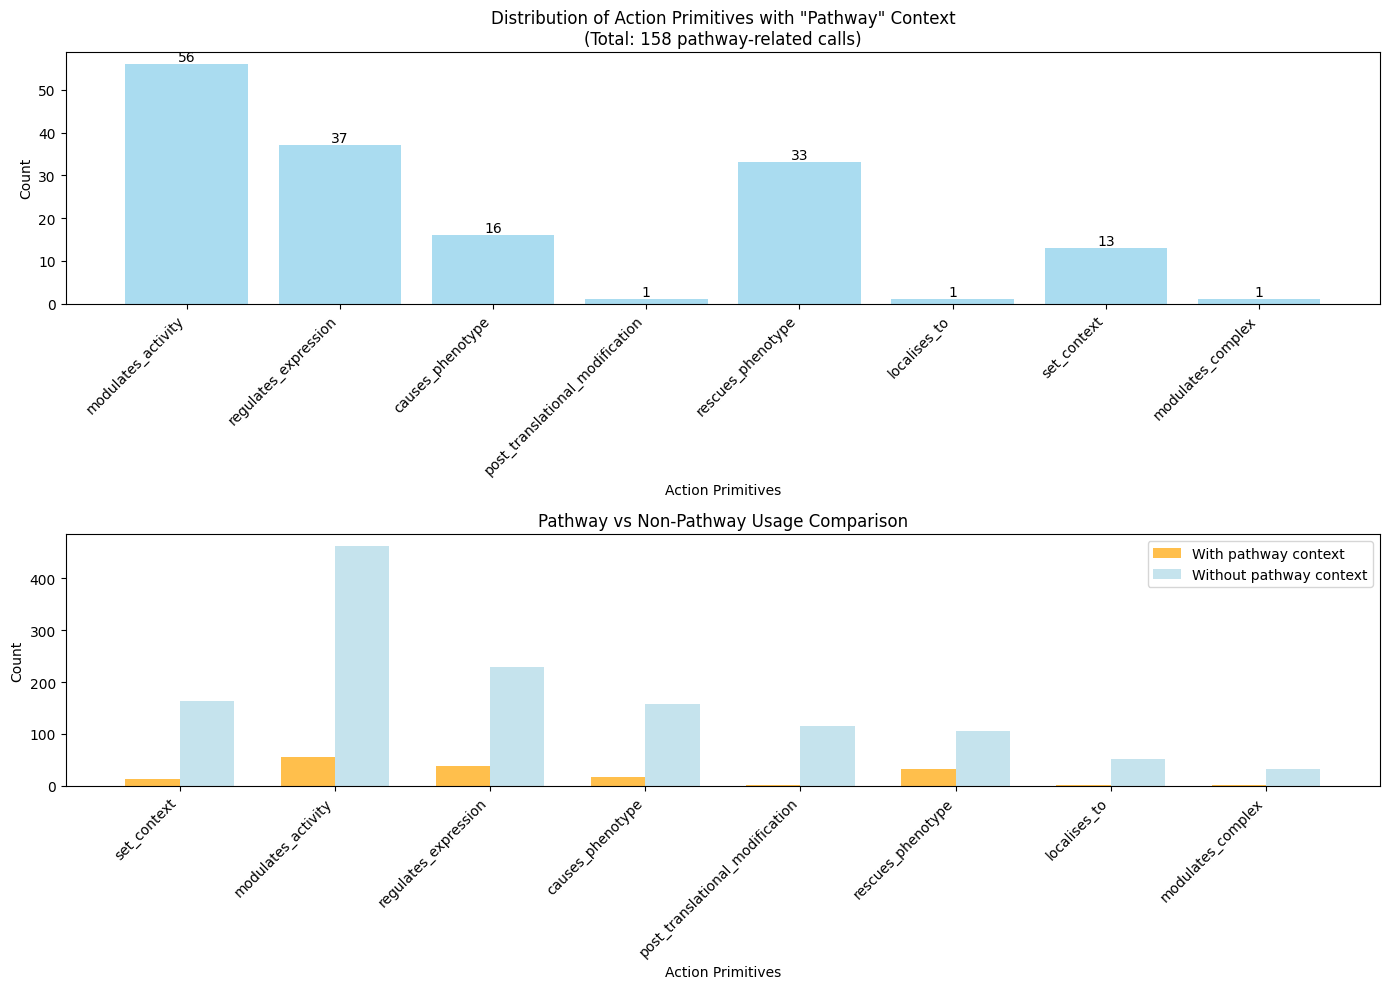


EXAMPLES OF PATHWAY-RELATED PRIMITIVE USAGE:

causes_phenotype (16 total occurrences):
  Example: causes_phenotype(id="n6", source="MAPK/ERK pathway", phenotype="decreased endothelial cell proliferation", via="impaired growth signaling")

localises_to (1 total occurrences):
  Example: localises_to(id="n3", entity="β-catenin", from_loc="cytoplasm", to_loc="nucleus", via="Wnt pathway activation")

modulates_activity (56 total occurrences):
  Example: modulates_activity(id="n3", entity="PI3K/Akt pathway", direction="down", via="blocked VEGFR-2 autophosphorylation")

modulates_complex (1 total occurrences):
  Example: modulates_complex(id="n2", members=["IL-6:sIL-6R", "gp130"], complex="IL-6:sIL-6R:gp130 hexamer", direction="up", via="trans-signaling pathway activation")

post_translational_modification (1 total occurrences):
  Example: post_translational_modification(id="n10", protein="Akt", mod_type="phosphorylation", site="Ser473", direction="down", via="PI3K pathway inhibition")

regu

In [17]:
import re

import matplotlib.pyplot as plt
import seaborn as sns

# Extract all action primitives from the dataset with their full context
pathway_primitives = []
pathway_primitive_counter = Counter()

print(f"Analyzing {len(df)} records for pathway-related primitives...")

for idx, row in df.iterrows():
    explain_content = row["explain"]
    if pd.notna(explain_content) and explain_content.strip():
        # Split into lines and analyze each action primitive line
        lines = explain_content.strip().split("\n")

        for line in lines:
            line = line.strip()
            if line and not line.startswith("#") and not line.startswith("//") and "(" in line:
                # Extract action name
                action_match = re.match(r"^([a-zA-Z_][a-zA-Z0-9_]*)\s*\(", line)
                if action_match:
                    action_name = action_match.group(1)

                    # Check if this line contains "pathway" (case insensitive)
                    if "pathway" in line.lower():
                        pathway_primitives.append({"action": action_name, "full_line": line, "record_idx": idx})
                        pathway_primitive_counter[action_name] += 1

print(f"\nTotal primitive calls: {len(all_primitives_used)}")
print(f"Pathway-related primitive calls: {len(pathway_primitives)}")
print(f"Percentage involving pathways: {len(pathway_primitives) / len(all_primitives_used) * 100:.1f}%")

print("\n" + "=" * 60)
print("PATHWAY-RELATED PRIMITIVES DISTRIBUTION:")

if pathway_primitive_counter:
    print("\nPrimitives used with 'pathway' context:")
    for action, count in pathway_primitive_counter.most_common():
        percentage = count / len(pathway_primitives) * 100
        print(f"  {action}: {count} times ({percentage:.1f}%)")

    # Create visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Plot 1: Distribution of pathway-related primitives
    actions = list(pathway_primitive_counter.keys())
    counts = list(pathway_primitive_counter.values())

    bars1 = ax1.bar(range(len(actions)), counts, color="skyblue", alpha=0.7)
    ax1.set_xlabel("Action Primitives")
    ax1.set_ylabel("Count")
    ax1.set_title(
        f'Distribution of Action Primitives with "Pathway" Context\n(Total: {len(pathway_primitives)} pathway-related calls)'
    )
    ax1.set_xticks(range(len(actions)))
    ax1.set_xticklabels(actions, rotation=45, ha="right")

    # Add count labels on bars
    for bar, count in zip(bars1, counts, strict=False):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2.0, height + 0.1, f"{count}", ha="center", va="bottom")

    # Plot 2: Comparison - pathway vs non-pathway usage
    filtered_actions = [action for action in primitive_counter.keys() if pathway_primitive_counter.get(action, 0) > 0]
    filtered_pathway = [pathway_primitive_counter[action] for action in filtered_actions]
    filtered_non_pathway = [
        primitive_counter[action] - pathway_primitive_counter[action] for action in filtered_actions
    ]

    x_pos = range(len(filtered_actions))
    width = 0.35

    bars2 = ax2.bar(
        [x - width / 2 for x in x_pos], filtered_pathway, width, label="With pathway context", color="orange", alpha=0.7
    )
    bars3 = ax2.bar(
        [x + width / 2 for x in x_pos],
        filtered_non_pathway,
        width,
        label="Without pathway context",
        color="lightblue",
        alpha=0.7,
    )

    ax2.set_xlabel("Action Primitives")
    ax2.set_ylabel("Count")
    ax2.set_title("Pathway vs Non-Pathway Usage Comparison")
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(filtered_actions, rotation=45, ha="right")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 60)
    print("EXAMPLES OF PATHWAY-RELATED PRIMITIVE USAGE:")

    # Group examples by action type and show 1 example per type
    examples_by_action = {}
    for item in pathway_primitives:
        action = item["action"]
        if action not in examples_by_action:
            examples_by_action[action] = []
        examples_by_action[action].append(item)

    # Show 1 example for each action type
    for action in sorted(examples_by_action.keys()):
        examples = examples_by_action[action]
        print(f"\n{action} ({len(examples)} total occurrences):")
        print(f"  Example: {examples[0]['full_line']}")

else:
    print("No pathway-related primitives found in the dataset.")